In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from heapq import merge

In [28]:



sales        = pd.read_csv('sales.csv')
traffic      = pd.read_csv('web_traffic.csv')
returns      = pd.read_csv('returns.csv')
reviews      = pd.read_csv('reviews.csv')
customers    = pd.read_csv('customers.csv')
orders       = pd.read_csv('orders.csv')
order_items  = pd.read_csv('order_items.csv')
payments     = pd.read_csv('payments.csv')
shipments    = pd.read_csv('shipments.csv')
inventory    = pd.read_csv('inventory.csv')
products     = pd.read_csv('products.csv')
geography    = pd.read_csv('geography.csv')
promotions   = pd.read_csv('promotions.csv')

# --- Ép kiểu datetime ---
sales['Date']                = pd.to_datetime(sales['Date'])
traffic['date']              = pd.to_datetime(traffic['date'])
returns['return_date']       = pd.to_datetime(returns['return_date'])
reviews['review_date']       = pd.to_datetime(reviews['review_date'])
customers['signup_date']     = pd.to_datetime(customers['signup_date'])
orders['order_date']         = pd.to_datetime(orders['order_date'])
shipments['ship_date']       = pd.to_datetime(shipments['ship_date'])
shipments['delivery_date']   = pd.to_datetime(shipments['delivery_date'])

# --- Tạo cột year, month từ sales để join với inventory (snapshot tháng) ---
sales['year']  = sales['Date'].dt.year
sales['month'] = sales['Date'].dt.month

# --- Ép kiểu cột 'zip' về string cho tất cả các bảng
orders['zip'] = orders['zip'].astype(str)
customers['zip'] = customers['zip'].astype(str)
geography['zip'] = geography['zip'].astype(str)

# --- Ép kiểu ID về 'int' để đồng bộ (vì ID đơn hàng thường là số nguyên)
orders['order_id']      = orders['order_id'].astype('int64')
order_items['order_id'] = order_items['order_id'].astype('int64')
payments['order_id']  = payments['order_id'].astype('int64')
shipments['order_id'] = shipments['order_id'].astype('int64')

# --- Ép kiểu cột 'zip' về string cho tất cả các bảng có cột này để tránh lỗi khi merge ---
customers['zip']        = customers['zip'].astype(str).str.strip()
orders['zip'] = orders['zip'].astype(str).str.strip()
geography['zip'] = geography['zip'].astype(str).str.strip()


# --- Ép kiểu customer_id để bước merge sau không bị lỗi
orders['customer_id'] = orders['customer_id'].astype('int64')
customers['customer_id'] = customers['customer_id'].astype('int64')

# --- Danh sách các bảng và các cột ID tương ứng ---
id_columns = ['order_id', 'customer_id', 'product_id']
zip_columns = ['zip']

# Handle zip separately as a STRING identifier
for df in [orders, payments, customers, order_items, geography, returns, reviews, shipments, inventory, products]:
    # Convert ID columns
    for col in id_columns:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()
    
    # Convert zip columns
    for col in zip_columns:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

C:\Users\MY COMPUTER\AppData\Local\Temp\ipykernel_11844\2678542634.py:7: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items  = pd.read_csv('order_items.csv')


In [29]:
# ============================================================
# BƯỚC 2: LÀM SẠCH DỮ LIỆU THIẾU
# ============================================================

# --- order_items: promo_id thiếu => điền '0' (không có khuyến mãi) ---
order_items['promo_id']   = order_items['promo_id'].fillna('0')
order_items['promo_id_2'] = order_items['promo_id_2'].fillna('0')

# --- promotions: applicable_category thiếu => điền 'All' (áp dụng toàn danh mục) ---
promotions['applicable_category'] = promotions['applicable_category'].fillna('All')

# --- payments: đảm bảo payment_value là số ---
payments['payment_value'] = pd.to_numeric(payments['payment_value'], errors='coerce').fillna(0)


In [30]:
# ============================================================
# BƯỚC 3: GOM NHÓM TỪNG BẢNG
# ============================================================

# --- 3.1. Web Traffic: tổng hợp theo ngày ---
traffic_daily = traffic.groupby('date').agg(
    total_sessions   = ('sessions',    'sum'),
    total_page_views = ('page_views',  'sum'),
    avg_bounce_rate  = ('bounce_rate', 'mean')
).reset_index()

# --- 3.2. Returns: tổng hợp theo ngày trả hàng ---
returns_daily = returns.groupby('return_date').agg(
    total_refund_amount  = ('refund_amount',   'sum'),
    total_returned_items = ('return_quantity', 'sum')
).reset_index()

# --- 3.3. Reviews: tổng hợp theo ngày đánh giá ---
reviews_daily = reviews.groupby('review_date').agg(
    avg_rating    = ('rating',    'mean'),
    total_reviews = ('review_id', 'count')
).reset_index()

# --- 3.4. Customers: đếm khách mới theo ngày đăng ký ---
customers_daily = customers.groupby('signup_date').agg(
    new_customers = ('customer_id', 'count')
).reset_index()

# --- 3.5. Orders + Payments + Shipments + Items: gom theo ngày đặt hàng ---
# Hợp nhất các bảng liên quan đến order
df_orders = (
    orders.drop(columns=['payment_method'], errors='ignore')
    .merge(payments, on='order_id', how='left')
    .merge(shipments, on='order_id', how='left')
)

items_agg = order_items.groupby('order_id').agg(
    total_discount = ('discount_amount', 'sum'),
    total_quantity = ('quantity',        'sum')
).reset_index()
df_orders = df_orders.merge(items_agg, on='order_id', how='left')

orders_daily = df_orders.groupby('order_date').agg(
    total_orders        = ('order_id',       'count'),
    total_payment_value = ('payment_value',  'sum'),
    total_shipping_fee  = ('shipping_fee',   'sum'),
    total_discount_given= ('total_discount', 'sum'),
    total_items_sold    = ('total_quantity', 'sum')
).reset_index()

# --- 3.6. Inventory: snapshot cuối tháng — gom theo year + month ---
inventory['year']  = pd.to_datetime(inventory['snapshot_date']).dt.year
inventory['month'] = pd.to_datetime(inventory['snapshot_date']).dt.month

inventory_monthly = inventory.groupby(['year', 'month']).agg(
    total_stock_on_hand  = ('stock_on_hand', 'sum'),
    avg_fill_rate        = ('fill_rate',     'mean'),
    total_stockout_days  = ('stockout_days', 'sum')
).reset_index()

In [31]:
# ============================================================
# BƯỚC 4: XÂY DỰNG BẢNG MASTER
# ============================================================
# Sales là bảng gốc; lần lượt join các bảng ngày, sau đó bảng tháng
df_master = sales.copy()

# --- Join các bảng có granularity ngày ---
df_master = df_master.merge(traffic_daily,   left_on='Date', right_on='date',        how='left')
df_master = df_master.merge(returns_daily,   left_on='Date', right_on='return_date', how='left')
df_master = df_master.merge(reviews_daily,   left_on='Date', right_on='review_date', how='left')
df_master = df_master.merge(customers_daily, left_on='Date', right_on='signup_date', how='left')
df_master = df_master.merge(orders_daily,    left_on='Date', right_on='order_date',  how='left')

# --- Join bảng tháng (Inventory) qua year + month ---
df_master = df_master.merge(inventory_monthly, on=['year', 'month'], how='left')

# --- Xử lý NaN sinh ra bởi Left Join ---
# Ngày không có dữ liệu tương ứng => điền 0; rating thiếu => điền trung bình
fill_zeros = [
    'total_refund_amount', 'total_returned_items',
    'new_customers', 'total_discount_given', 'total_shipping_fee'
]
df_master[fill_zeros] = df_master[fill_zeros].fillna(0)
df_master['avg_rating'] = df_master['avg_rating'].fillna(df_master['avg_rating'].mean())

# --- Xóa các cột key thừa sau khi join ---
cols_to_drop = ['date', 'return_date', 'review_date', 'signup_date', 'order_date']
df_master.drop(columns=[c for c in cols_to_drop if c in df_master.columns], inplace=True)

print(f'Bảng Master: {df_master.shape[0]} dòng x {df_master.shape[1]} cột')
df_master.head()
for col in df_master.columns:
    print(col)

Bảng Master: 3833 dòng x 21 cột
Date
Revenue
COGS
year
month
total_sessions
total_page_views
avg_bounce_rate
total_refund_amount
total_returned_items
avg_rating
total_reviews
new_customers
total_orders
total_payment_value
total_shipping_fee
total_discount_given
total_items_sold
total_stock_on_hand
avg_fill_rate
total_stockout_days


In [32]:
#df_master["log_revenue"] = np.log1p(df_master["Revenue"])

In [33]:
df_master["total_sessions"].corr(df_master["Revenue"], method="spearman")

np.float64(0.36839001891831924)

In [34]:
df_master["conversion_rate"] = df_master["total_orders"] / df_master["total_sessions"]
df_master["aov"] = df_master["Revenue"] / df_master["total_orders"]
df_master["rev_per_session"] = df_master["Revenue"] / df_master["total_sessions"]
df_master["discount_ratio"] = df_master["total_discount_given"] / df_master["total_payment_value"]
df_master["return_rate"] = df_master["total_returned_items"] / df_master["total_items_sold"]
df_master["stock_efficiency"] = df_master["total_items_sold"] / df_master["total_stock_on_hand"]
df_master["sessions_x_conv"] = df_master["total_sessions"] * df_master["conversion_rate"]
df_master["price_effect"] = df_master["aov"] * df_master["conversion_rate"]

KeyError: 'log_revenue'

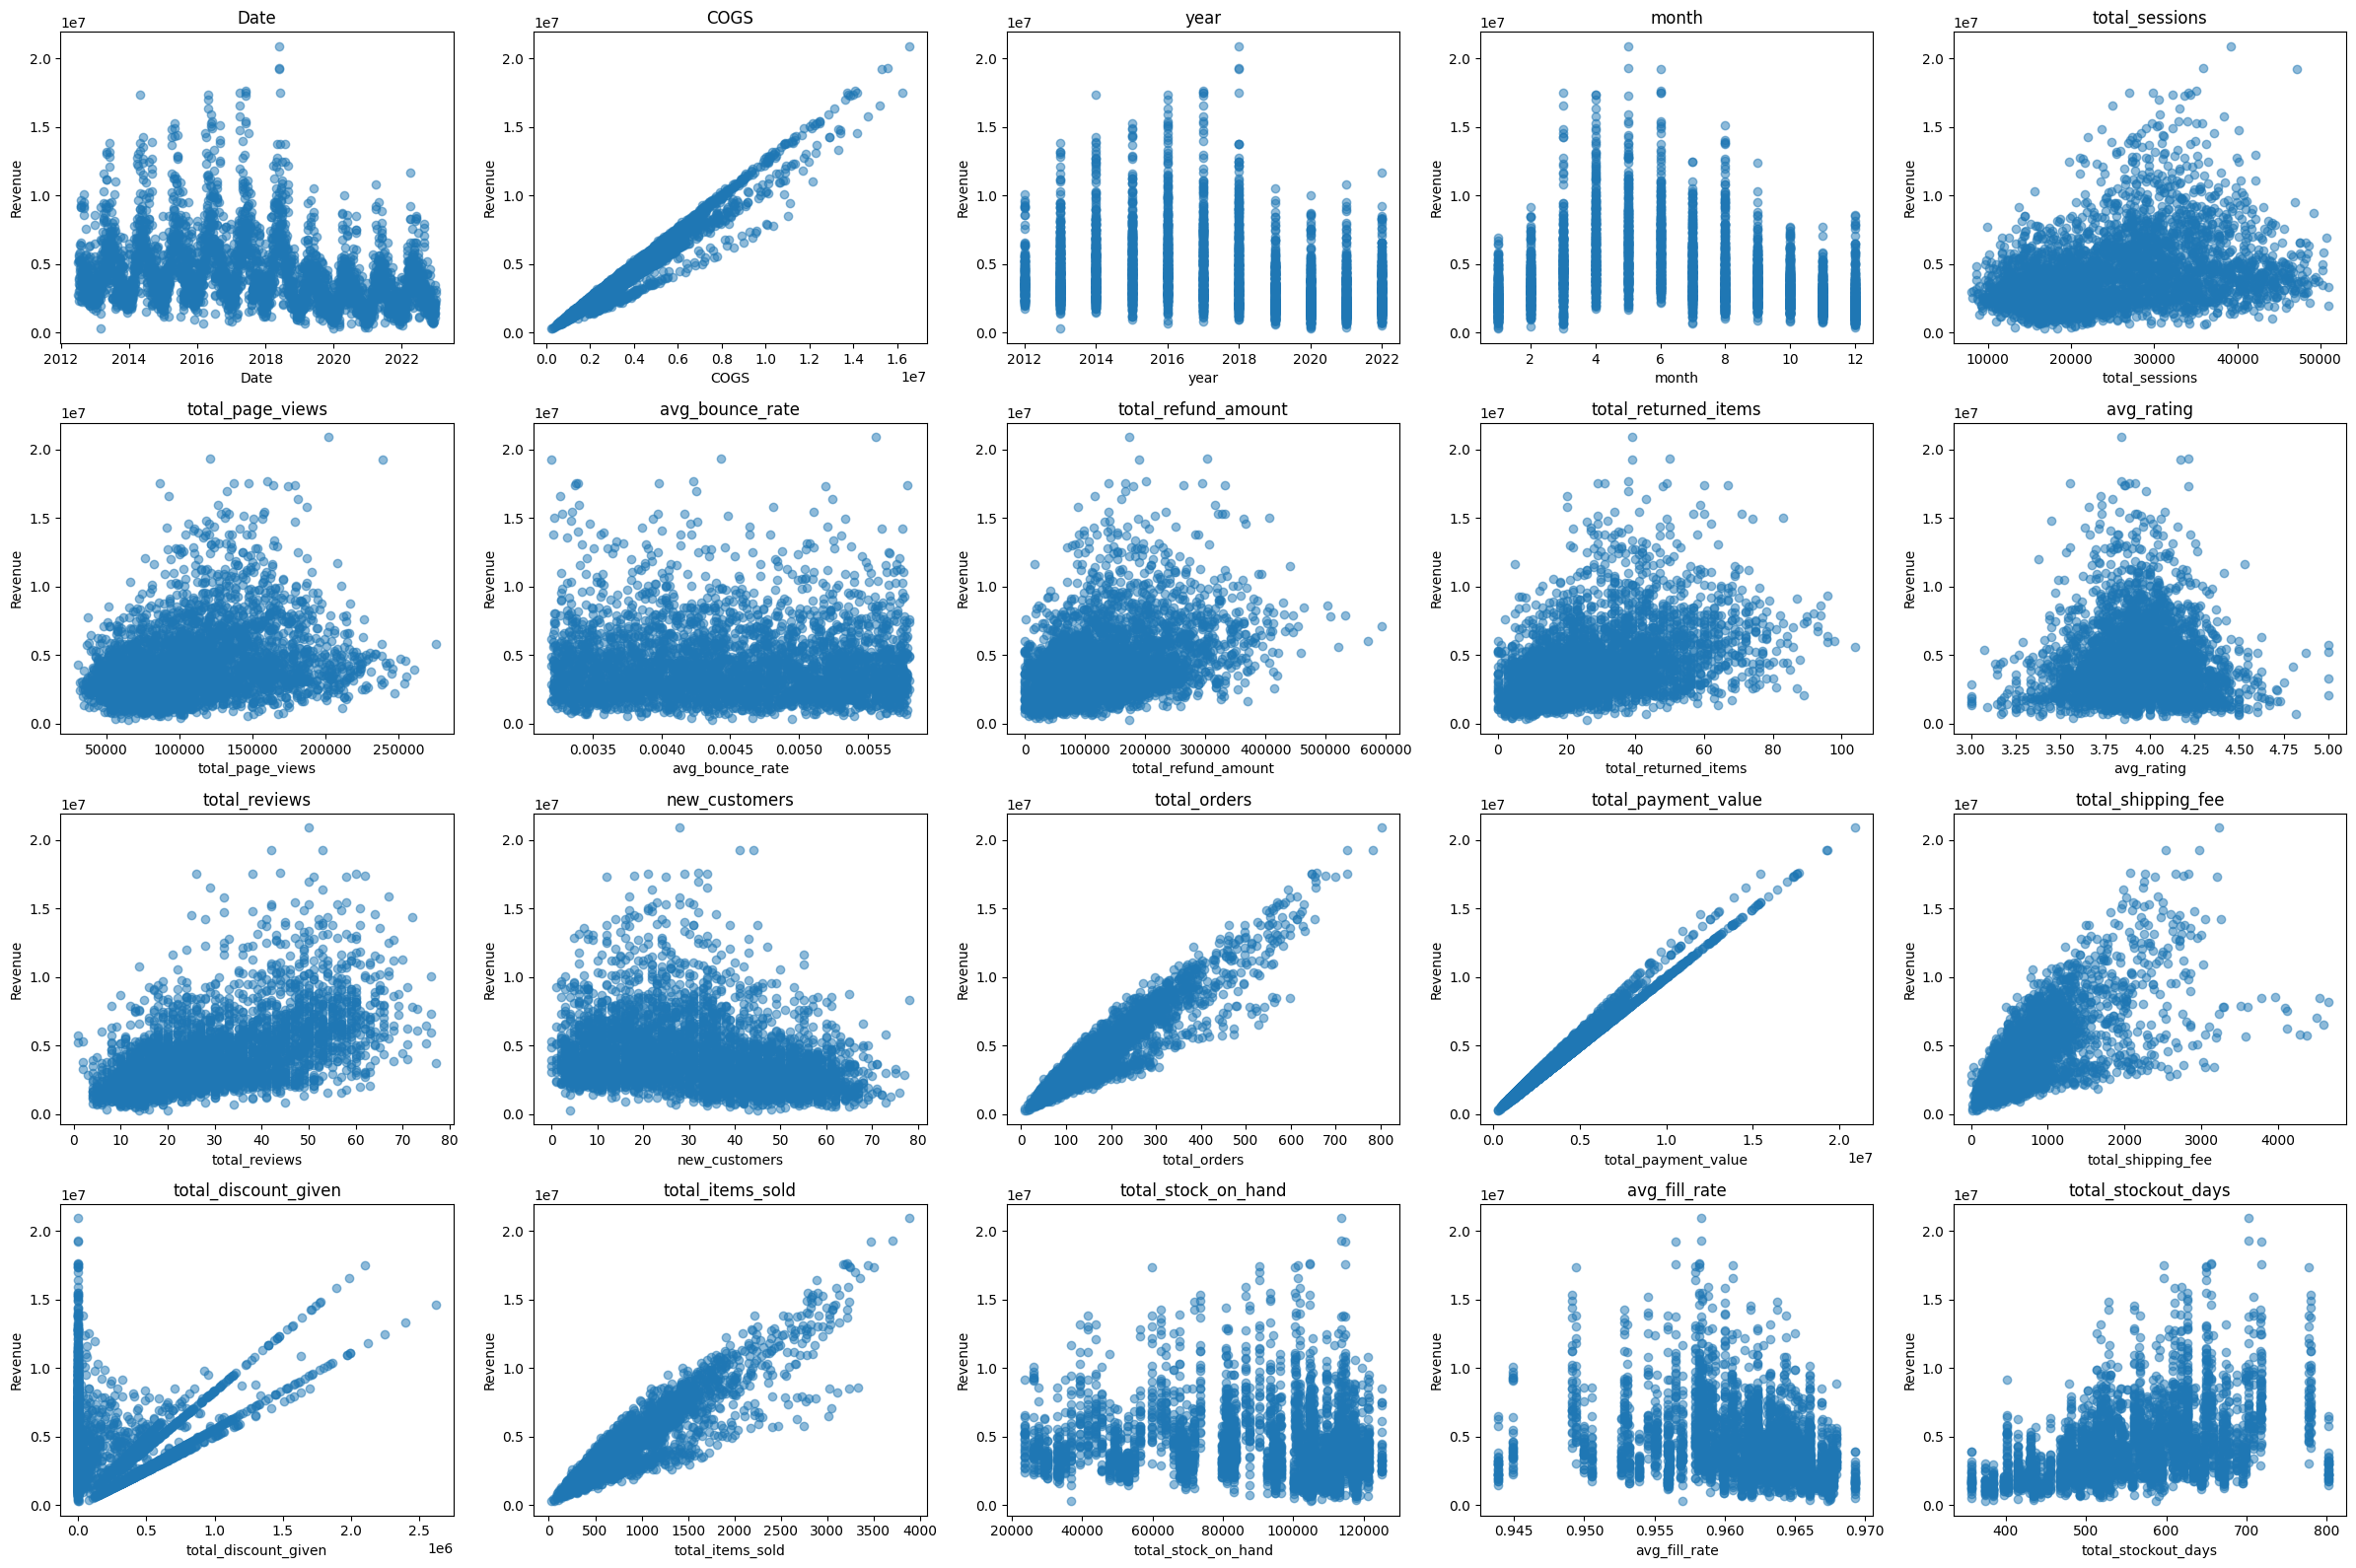

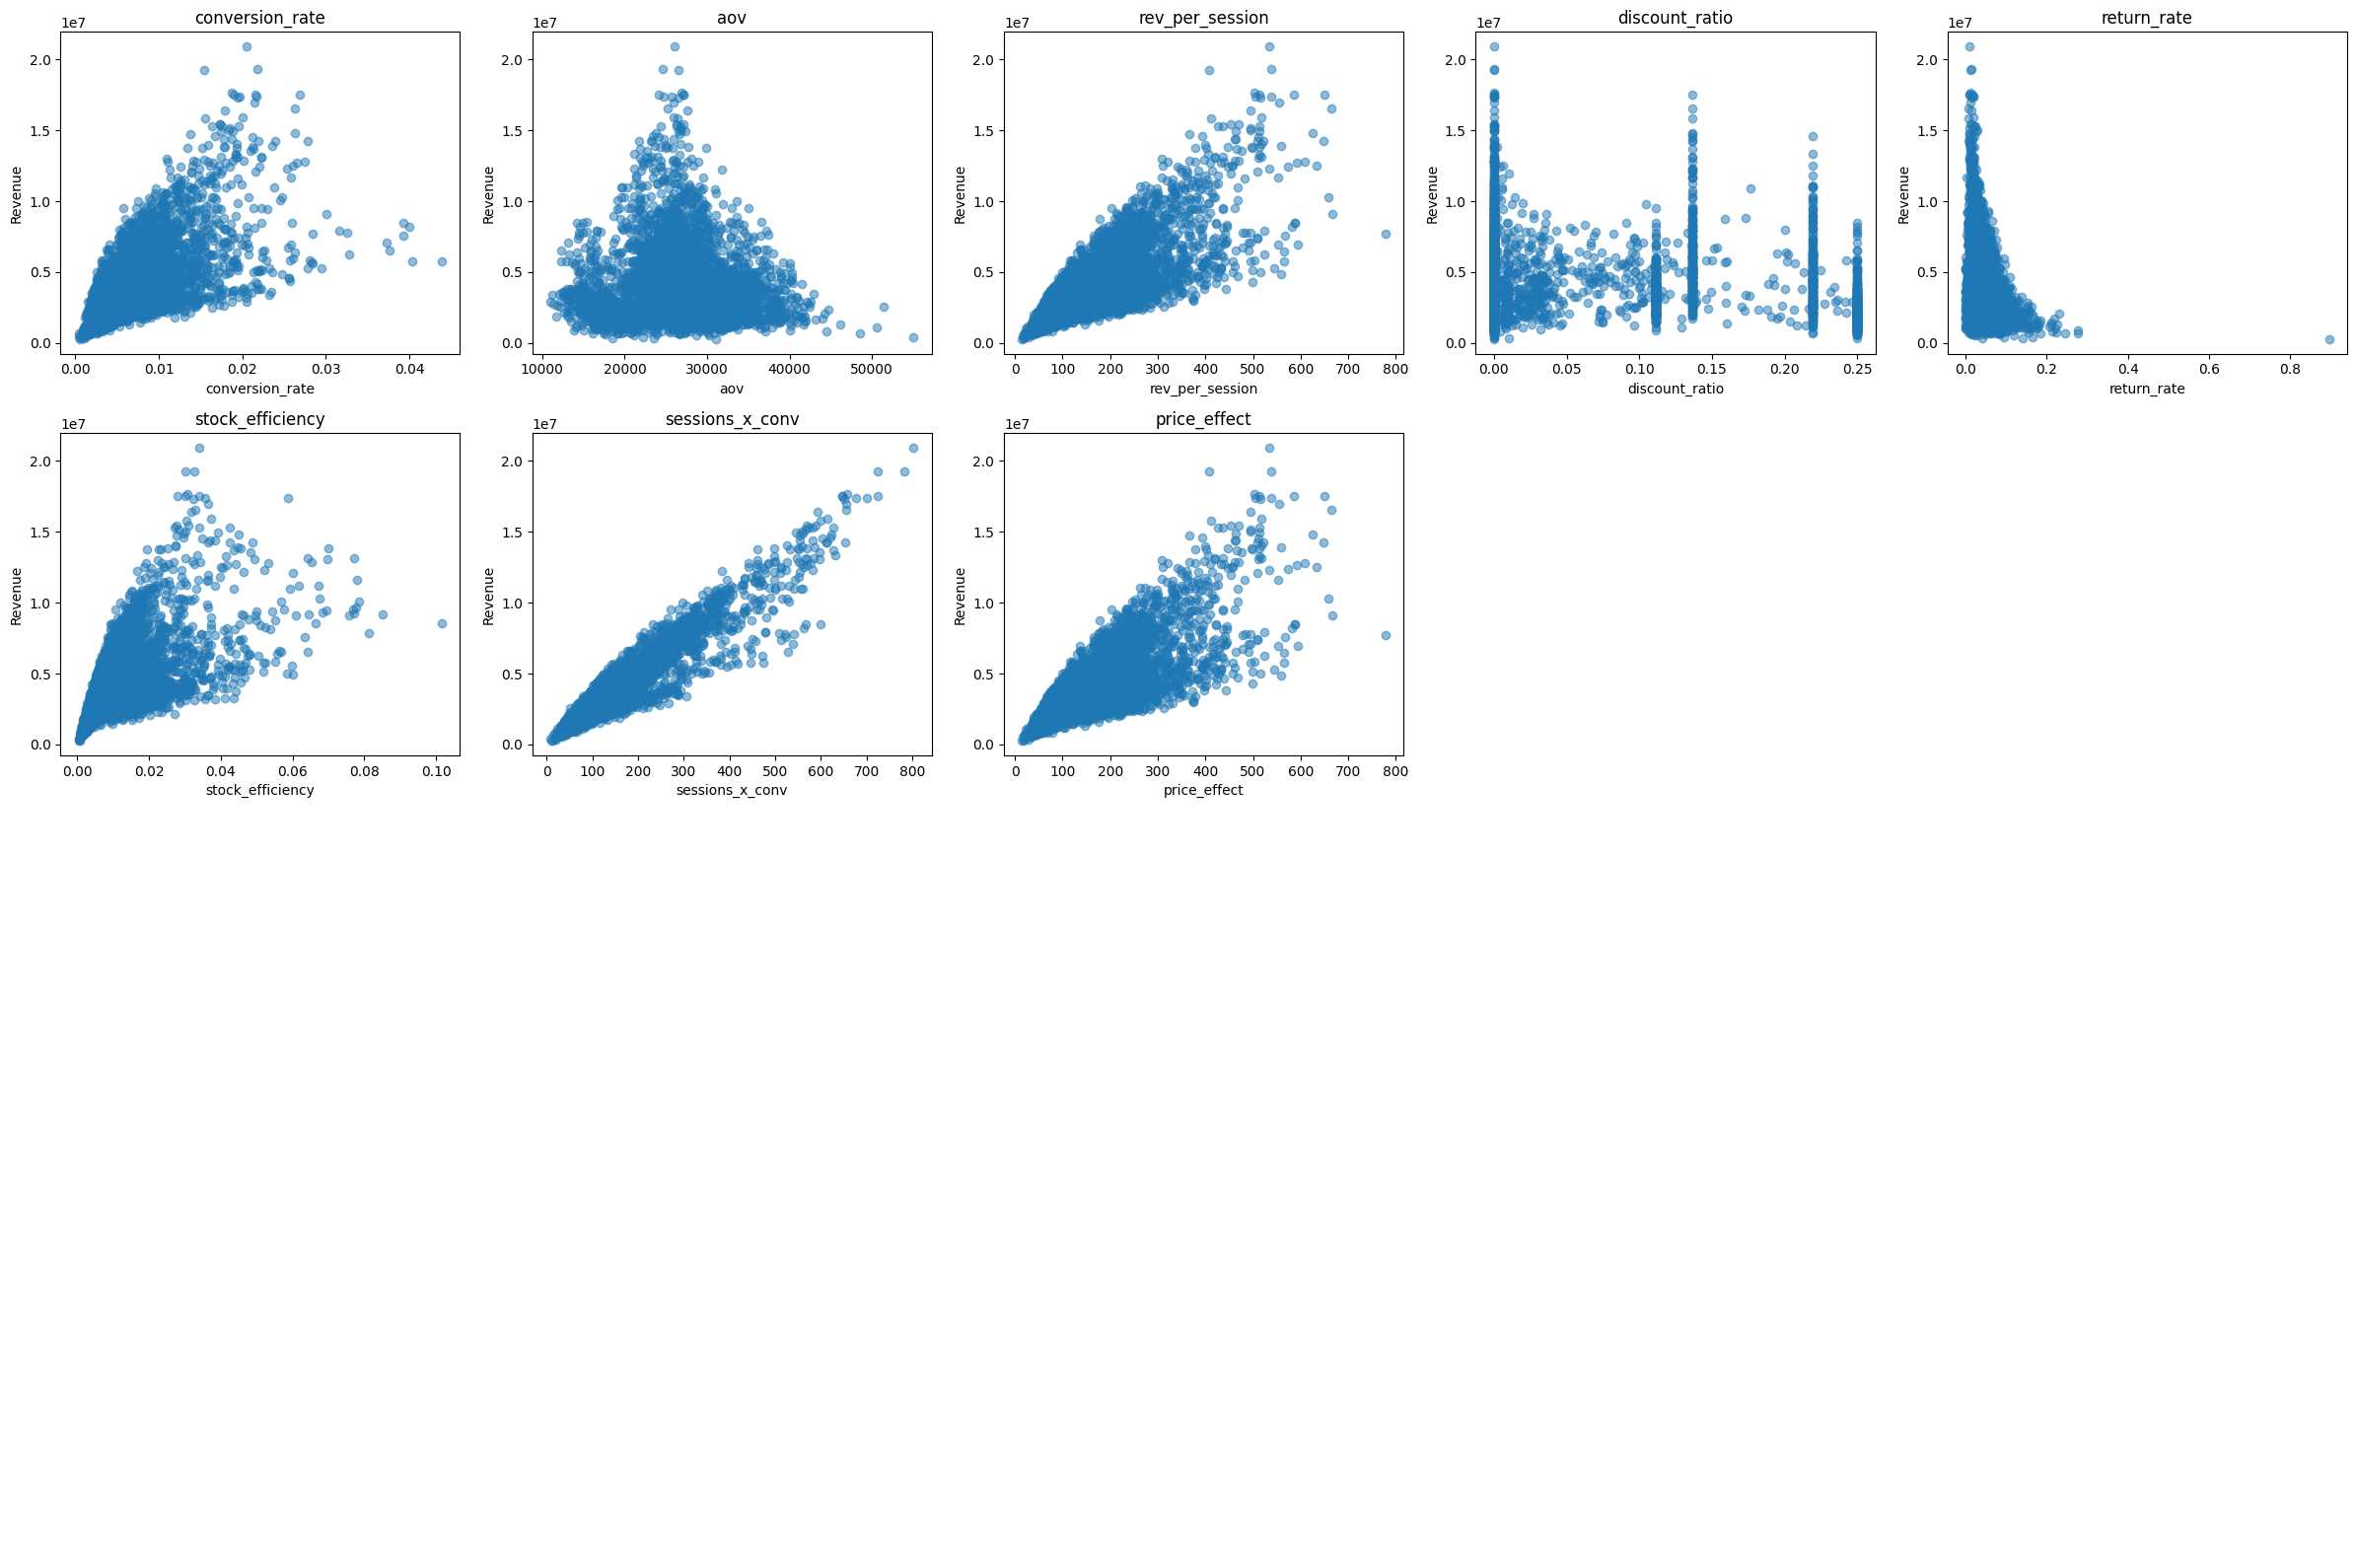

In [36]:
import matplotlib.pyplot as plt

target = "Revenue"
features = [col for col in df_master.columns if col != target]

cols = 5
rows = 4

for i in range(0, len(features), cols * rows):
    subset = features[i:i + cols * rows]

    fig, axes = plt.subplots(rows, cols, figsize=(24, 16))
    axes = axes.flatten()

    for j, col in enumerate(subset):
        axes[j].scatter(df_master[col], df_master[target], alpha=0.5)
        axes[j].set_title(col)
        axes[j].set_xlabel(col)
        axes[j].set_ylabel(target)

    for k in range(j + 1, len(axes)):
        axes[k].axis("off")

    plt.tight_layout()
    plt.show()

,Date,Revenue,COGS,year,month,total_sessions,total_page_views,avg_bounce_rate,total_refund_amount,total_returned_items,...,total_stockout_days,log_revenue,conversion_rate,aov,rev_per_session,discount_ratio,return_rate,stock_efficiency,sessions_x_conv,price_effect
0,2012-07-04,5123547.94,3982991.19,2012,7,NaN,NaN,NaN,0.00,0.0,...,402,15.449358,NaN,31626.839136,NaN,0.000000,0.000000,0.032788,NaN,NaN
1,2012-07-05,2751773.45,2150580.23,2012,7,NaN,NaN,NaN,0.00,0.0,...,402,14.827757,NaN,28368.798454,NaN,0.000000,0.000000,0.018061,NaN,NaN
2,2012-07-06,3054029.42,2517632.84,2012,7,NaN,NaN,NaN,0.00,0.0,...,402,14.931973,NaN,32839.026022,NaN,0.000000,0.000000,0.018609,NaN,NaN
3,2012-07-07,2667930.94,2108246.62,2012,7,NaN,NaN,NaN,0.00,0.0,...,402,14.796814,NaN,36546.999178,NaN,0.000000,0.000000,0.015360,NaN,NaN
4,2012-07-08,2360851.90,1808622.79,2012,7,NaN,NaN,NaN,0.00,0.0,...,402,14.674534,NaN,26827.862500,NaN,0.000000,0.000000,0.016626,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3828,2022-12-27,2100553.66,2184872.24,2022,12,17416.0,62527.0,0.00506,26482.11,5.0,...,493,14.557712,0.006201,19449.570926,120.610568,0.250000,0.008347,0.005747,108.0,120.610568
3829,2022-12-28,3448729.20,3513621.00,2022,12,21071.0,67456.0,0.00560,97387.35,19.0,...,493,15.053517,0.007783,21028.836585,163.671833,0.250000,0.021088,0.008644,164.0,163.671833
3830,2022-12-29,3083944.33,3170787.10,2022,12,20884.0,82155.0,0.00522,20897.84,7.0,...,493,14.941720,0.006847,21566.044266,147.670194,0.250000,0.010234,0.006562,143.0,147.670194
3831,2022-12-30,2884668.76,3022292.15,2022,12,17679.0,79308.0,0.00350,43613.12,16.0,...,493,14.874921,0.005996,27213.856226,163.169227,0.241575,0.031873,0.004816,106.0,163.169227


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:Date: datetime64[ns]

In [37]:
df_master.to_csv("C:/VinDATATHON/out.csv", index=False)

In [ ]:
DROP_REDUNDANT = [
    'log_sessions_x_conv',
    'sessions_x_conv_calc', 
    'log_orders_x_aov',
    'orders_x_aov',
    'log_total_items_sold',
    'log_total_orders',
    
]